In [31]:
import pandas as pd
import numpy as np
import re
import math
from urllib.parse import urlparse
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [32]:
# Load CSV file
df = pd.read_csv('dataset/owndataset.csv')
print(f"✅ Dataset loaded: {len(df)} rows")
print(f"📊 Columns: {df.columns.tolist()}")
print(f"\n📈 Status Distribution:\n{df['classlabel'].value_counts()}")


✅ Dataset loaded: 19431 rows
📊 Columns: ['url', 'url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars', 'has_phishing_keyword', 'is_trusted_domain', 'classlabel']

📈 Status Distribution:
classlabel
0    9716
1    9715
Name: count, dtype: int64


In [33]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv("dataset/owndataset.csv")

# =========================
# LABEL
# 0 = legitimate, 1 = phishing
# =========================
y = df["classlabel"]

In [34]:
print(y.value_counts())

classlabel
0    9716
1    9715
Name: count, dtype: int64


In [35]:
df = df.drop_duplicates()

In [36]:
feature_names = [
    "url_length","has_ip_address","dot_count","https_flag","url_entropy",
    "token_count","subdomain_count","query_param_count",
    "tld_length","path_length","has_hyphen_in_domain",
    "number_of_digits","tld_popularity","suspicious_file_extension",
    "domain_name_length","percentage_numeric_chars",
    "has_at_symbol","has_double_slash","has_equal_sign",
    "has_phishing_keyword","is_trusted_domain"
]

In [37]:
import re
import math
from urllib.parse import urlparse
from collections import Counter

# =========================
# ENTROPY FUNCTION
# =========================
def entropy(text):
    if not text:
        return 0
    prob = [count / len(text) for count in Counter(text).values()]
    return -sum(p * math.log2(p) for p in prob if p > 0)

# =========================
# TRUSTED DOMAIN
# =========================
trusted_domains = [
    "google.com", "youtube.com",
    "facebook.com", "instagram.com",
    "shopee.co.id", "tokopedia.com"
]

# =========================
# PHISHING KEYWORDS
# =========================
phishing_keywords = [
    "login", "verify", "update", "secure",
    "account", "bank", "confirm", "password"
]

# =========================
# FEATURE EXTRACTION (UPDATED)
# =========================
def extract_features(url):
    try:
        url = str(url)
        parsed = urlparse(url)

        domain = parsed.netloc.lower()
        path = parsed.path.lower()
        query = parsed.query.lower()

        # =========================
        # BASIC FEATURES
        # =========================

        url_length = len(url)

        has_ip_address = 1 if re.search(r'(\d{1,3}\.){3}\d{1,3}', url) else 0

        dot_count = domain.count('.')

        https_flag = 1 if parsed.scheme == "https" else 0

        url_entropy = entropy(url)

        tokens = re.split(r'[./\-?=&]', url)
        token_count = len([t for t in tokens if t])

        parts = domain.split('.')
        subdomain_count = max(len(parts) - 2, 0)

        query_param_count = len(query.split('&')) if query else 0

        tld = parts[-1] if parts else ""
        tld_length = len(tld)

        path_length = len(parsed.path)

        has_hyphen_in_domain = 1 if "-" in domain else 0

        number_of_digits = sum(c.isdigit() for c in url)

        popular_tlds = ["com", "org", "net", "id", "co", "io"]
        tld_popularity = 1 if tld in popular_tlds else 0

        suspicious_file_extension = 1 if parsed.path.endswith(
            (".php", ".exe", ".zip", ".js")
        ) else 0

        domain_name_length = len(domain)

        percentage_numeric_chars = number_of_digits / url_length if url_length > 0 else 0

        # =========================
        # NEW FEATURES (IMPROVEMENT)
        # =========================

        has_at_symbol = 1 if "@" in url else 0

        has_double_slash = 1 if "//" in url[8:] else 0

        has_equal_sign = 1 if "=" in url else 0

        url_lower = url.lower()

        has_phishing_keyword = 1 if any(k in url_lower for k in phishing_keywords) else 0

        is_trusted_domain = 1 if any(domain.endswith(td) for td in trusted_domains) else 0

        # =========================
        # FINAL FEATURE VECTOR
        # =========================

        return [
            url_length,
            has_ip_address,
            dot_count,
            https_flag,
            url_entropy,
            token_count,
            subdomain_count,
            query_param_count,
            tld_length,
            path_length,
            has_hyphen_in_domain,
            number_of_digits,
            tld_popularity,
            suspicious_file_extension,
            domain_name_length,
            percentage_numeric_chars,
            has_at_symbol,
            has_double_slash,
            has_equal_sign,
            has_phishing_keyword,
            is_trusted_domain
        ]

    except Exception as e:
        # jumlah fitur HARUS sama
        return [0] * 21

In [38]:
# %% [markdown]
# ## 4. Ekstraksi Fitur untuk Semua URL

print("🔄 Mengekstrak fitur dari URLs...")

# Apply feature extraction ke setiap URL
features_list = df['url'].apply(extract_features)

# Convert list of lists ke DataFrame
feature_names = [
    'url_length', 'has_ip_address', 'dot_count', 'https_flag',
    'url_entropy', 'token_count', 'subdomain_count', 'query_param_count',
    'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits',
    'tld_popularity', 'suspicious_file_extension', 'domain_name_length',
    'percentage_numeric_chars', "has_at_symbol",
    "has_double_slash", "has_equal_sign",
    'has_phishing_keyword', 'is_trusted_domain'
]

features_df = pd.DataFrame(features_list.tolist(), columns=feature_names)

# Gabungkan dengan label
df_final = pd.concat([features_df, df['classlabel']], axis=1)

# Convert label ke numeric (phishing=1, legitimate=0)
df_final['label'] = df_final['classlabel'].map({'phishing': 1, 'legitimate': 0})

print(f"✅ Fitur berhasil diekstrak!")
print(f"📊 Shape dataset: {df_final.shape}")
print(f"\n📋 Kolom fitur:\n{feature_names}")

🔄 Mengekstrak fitur dari URLs...
✅ Fitur berhasil diekstrak!
📊 Shape dataset: (13820, 23)

📋 Kolom fitur:
['url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars', 'has_at_symbol', 'has_double_slash', 'has_equal_sign', 'has_phishing_keyword', 'is_trusted_domain']


In [39]:
# %% [markdown]
# ## 5. Preview Data

print("\n🔍 Preview 5 baris pertama:")
display(df_final.head())

print(f"\n📈 Label Distribution:\n{df_final['label'].value_counts()}")


🔍 Preview 5 baris pertama:


,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,...,suspicious_file_extension,domain_name_length,percentage_numeric_chars,has_at_symbol,has_double_slash,has_equal_sign,has_phishing_keyword,is_trusted_domain,classlabel,label
0,46.0,0.0,2.0,0.0,4.615422,8.0,1.0,1.0,3.0,10.0,...,0.0,20.0,0.108696,0.0,0.0,1.0,0.0,0.0,1.0,NaN
1,128.0,0.0,10.0,0.0,4.568665,12.0,9.0,0.0,3.0,1.0,...,0.0,120.0,0.054688,0.0,0.0,0.0,0.0,0.0,1.0,NaN
2,52.0,0.0,2.0,0.0,4.192678,7.0,1.0,0.0,3.0,20.0,...,0.0,25.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,NaN
3,21.0,0.0,2.0,0.0,3.653757,4.0,1.0,0.0,3.0,1.0,...,0.0,13.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,28.0,0.0,2.0,1.0,4.012188,4.0,1.0,0.0,3.0,1.0,...,0.0,19.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN



📈 Label Distribution:
Series([], Name: count, dtype: int64)


In [40]:
# Tentukan nama file
filename = 'dataset/3fitur.csv'

# Save ke CSV
df_final.to_csv(filename, index=False, encoding='utf-8')

# Konfirmasi
print(f"✅ File berhasil disimpan: {filename}")

PermissionError: [Errno 13] Permission denied: 'dataset/3fitur.csv'

In [ ]:
import pandas as pd

df = pd.read_csv("dataset/3fitur.csv")

print(df.head())

                                                 url  url_length  \
0     http://www.progarchives.com/album.asp?id=61737          46   
1  http://signin.eday.co.uk.ws.edayisapi.dllsign....         128   
2  http://www.avevaconstruction.com/blesstool/ima...          52   
3                              http://www.jp519.com/          21   
4                       https://www.velocidrone.com/          28   

   has_ip_address  dot_count  https_flag  url_entropy  token_count  \
0               0          2           0     4.615422            8   
1               0         10           0     4.568665           12   
2               0          2           0     4.192678            7   
3               0          2           0     3.653757            4   
4               0          2           1     4.012188            4   

   subdomain_count  query_param_count  tld_length  ...  tld_popularity  \
0                1                  1           3  ...               1   
1                9    

In [ ]:
print(f"📊 Columns: {df.columns.tolist()}")

📊 Columns: ['url', 'url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars', 'has_at_symbol', 'has_double_slash', 'has_equal_sign', 'has_phishing_keyword', 'is_trusted_domain', 'classlabel']


In [7]:
import sys
print(sys.executable)

c:\Users\Asus\AppData\Local\Programs\Python\Python310\python.exe


In [8]:
!pip install joblib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Asus\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import joblib
import numpy as np
import re
import math

from urllib.parse import urlparse
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

In [3]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv("dataset/3fitur.csv")

# =========================
# LABEL
# 0 = legitimate, 1 = phishing
# =========================
y = df["classlabel"]


In [5]:
print(df["classlabel"].isnull().sum())

0


In [6]:
df = df.dropna(subset=["classlabel"])

In [7]:
X = []
y = df["classlabel"]

# safety check
print("NaN label:", y.isnull().sum())

NaN label: 0


In [8]:
# =========================
# CLEAN DATA (IMPORTANT)
# =========================
df = df.dropna(subset=["classlabel"])
df = df.dropna(subset=["url"])

df["classlabel"] = pd.to_numeric(df["classlabel"], errors="coerce")
df = df.dropna(subset=["classlabel"])
df["classlabel"] = df["classlabel"].astype(int)

y = df["classlabel"]

In [9]:
df = df.dropna(subset=["url", "classlabel"])
df = df.reset_index(drop=True)

In [10]:
X = []
y = []

for i, url in enumerate(df["url"]):
    try:
        feat = extract_features(url)

        # validasi fitur tidak None
        if feat is None:
            continue

        X.append(feat)
        y.append(df["classlabel"].iloc[i])

    except Exception as e:
        print(f"Error URL: {url} -> {e}")

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.model_selection import RandomizedSearchCV

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

search = RandomizedSearchCV(model, param_dist, cv=5, n_iter=10, n_jobs=-1)
search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}


In [34]:
# =========================================================
# 1. RANDOM FOREST (MAIN MODEL - CONTROL OVERFITTING)
# =========================================================
rf = RandomForestClassifier(
    n_estimators=700,
    max_depth=15,          # lebih kecil dari sebelumnya
    min_samples_split=2,  # diperbesar
    min_samples_leaf=1,    # diperbesar
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=700, random_state=42)

In [35]:
# =========================
# EVALUATION FUNCTION
# =========================
def evaluate(model, name):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"\n===== {name} =====")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print(classification_report(y_test, model.predict(X_test)))

In [36]:
evaluate(rf, "Random Forest")


===== Random Forest =====
Train Accuracy: 0.9458863318873613
Test Accuracy: 0.9003430531732418
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      2915
           1       0.92      0.88      0.90      2915

    accuracy                           0.90      5830
   macro avg       0.90      0.90      0.90      5830
weighted avg       0.90      0.90      0.90      5830



In [41]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2698  217]
 [ 364 2551]]


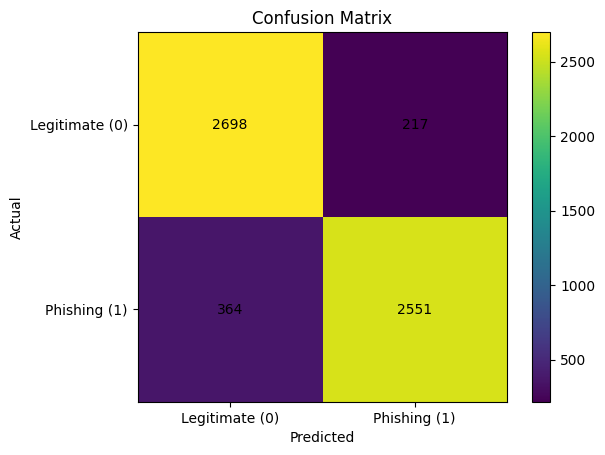

In [42]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([1,0], ["Phishing (1)", "Legitimate (0)"])
plt.yticks([1,0], ["Phishing (1)", "Legitimate (0)"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print(scores.mean())

0.9236781723948588
